# Imports

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import tqdm
from collections import Counter

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc

# Setting

In [233]:
# set font size
plt.rcParams.update({'font.size': 16})

In [234]:
# fix all seeds
import random
random.seed(42)
np.random.seed(42)

# Load data

In [235]:
DATA = "/home/jovyan/wf-bulk-senescence/data/Supplementary table 1 transcriptomic results.xlsx"

def prepare_adata(path):
    df = pd.read_excel(DATA)
    # get rowws where converted_alias is NaN
    print(f"Removing {len(df[df['converted_alias'].isna()])} rows with NaN converted_alias")
    # drop rows where converted_alias is NaN
    df = df.dropna(subset=['converted_alias'])
    # fill missing values with 0
    df.fillna(0, inplace=True)

    var = df[['converted_alias', 'name']]
    var.set_index('converted_alias', inplace=True)

    df.drop(columns=['name'], inplace=True)
    df = df.set_index('converted_alias')

    obs = pd.DataFrame(df.columns.values, columns=['obs'])
    obs['celltype'] = obs['obs'].str.split('_').str[0]
    obs['treatment'] = obs['obs'].str.split('_').str[1]
    obs['replicate'] = obs['obs'].str.split('_').str[2]
    obs.set_index('obs', inplace=True)

    adata = sc.AnnData(df.T, obs=obs, var=var)

    return adata

adata = prepare_adata(DATA)
adata


Removing 151 rows with NaN converted_alias


AnnData object with n_obs × n_vars = 190 × 53321
    obs: 'celltype', 'treatment', 'replicate'
    var: 'name'

In [236]:
adata.obs

,celltype,treatment,replicate
obs,,,
WI38_P_1,WI38,P,1
WI38_P_2,WI38,P,2
WI38_P_3,WI38,P,3
WI38_P_4,WI38,P,4
WI38_CTIS_1,WI38,CTIS,1
...,...,...,...
HEMn_CTIS_4,HEMn,CTIS,4
HEMn_IRIS_1,HEMn,IRIS,1
HEMn_IRIS_2,HEMn,IRIS,2


In [237]:
adata.var

,name
converted_alias,
ENSG00000277739,5_8S_rRNA
ENSG00000276861,5S_rRNA
ENSG00000277411,5S_rRNA
ENSG00000277488,5S_rRNA
ENSG00000285609,5S_rRNA
...,...
ENSG00000232242,ZYG11AP1
ENSG00000162378,ZYG11B
ENSG00000159840,ZYX


# Quality checks

In [238]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var['name'].str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var['name'].str.startswith(("RPS", "RPL")) | adata.var['name'].str.contains("rRNA")
# hemoglobin genes
adata.var["hb"] = adata.var['name'].str.contains("^HB[^(P)]")

adata.var

,name,mt,ribo,hb
converted_alias,,,,
ENSG00000277739,5_8S_rRNA,False,True,False
ENSG00000276861,5S_rRNA,False,True,False
ENSG00000277411,5S_rRNA,False,True,False
ENSG00000277488,5S_rRNA,False,True,False
ENSG00000285609,5S_rRNA,False,True,False
...,...,...,...,...
ENSG00000232242,ZYG11AP1,False,False,False
ENSG00000162378,ZYG11B,False,False,False
ENSG00000159840,ZYX,False,False,False


In [239]:
# convert metrics columns to bool
adata.var["mt"] = adata.var["mt"].astype(bool)
adata.var["ribo"] = adata.var["ribo"].astype(bool)
adata.var["hb"] = adata.var["hb"].astype(bool)

In [240]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=False
)

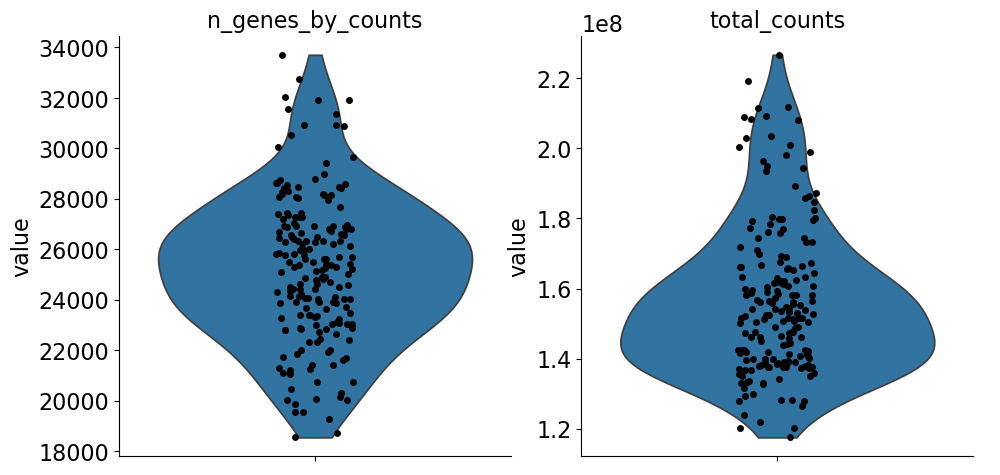

In [241]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    multi_panel=True,
    size=5
)

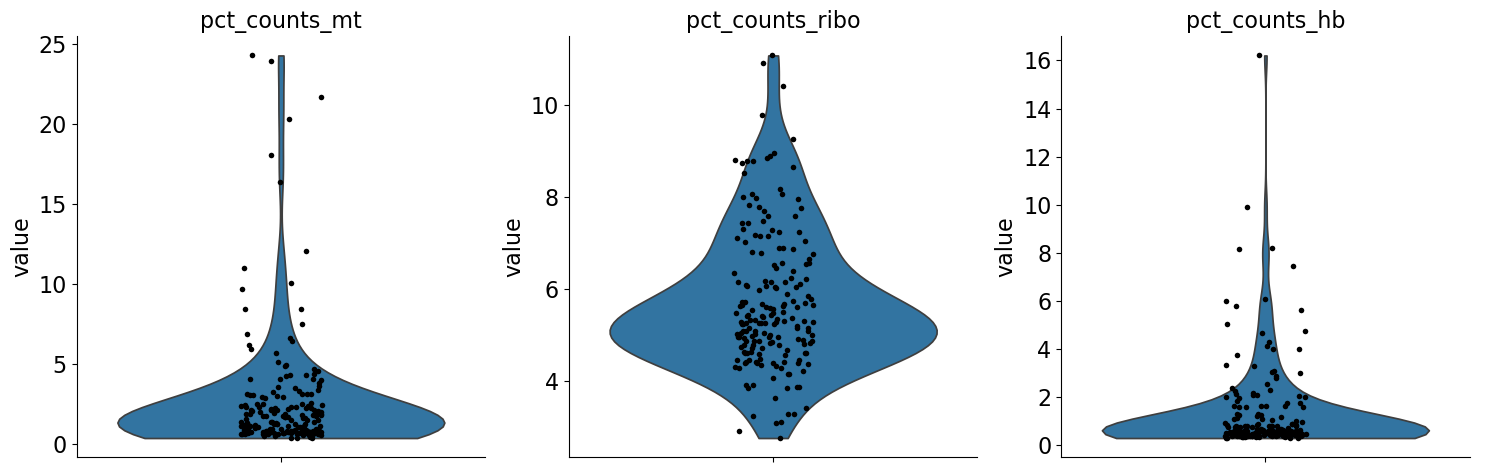

In [242]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    size=4,
    multi_panel=True
)

In [243]:
adata.obs[adata.obs['pct_counts_mt'] > 10].sort_values('pct_counts_mt', ascending=False)[
    ['celltype', 'treatment', 'replicate', 'pct_counts_hb', 'pct_counts_mt', 'pct_counts_ribo']
].reset_index(drop=True)

,celltype,treatment,replicate,pct_counts_hb,pct_counts_mt,pct_counts_ribo
0,PBMC,IRIS,2,0.369618,24.283535,3.275740
1,PBMC,IRIS,4,0.304694,23.922333,3.116578
2,PBMC,IRIS,1,0.314312,21.673562,3.229160
3,PBMC,IRIS,3,0.335684,20.284708,3.286127
4,PBMC,CTIS,3,0.380877,18.069419,4.578123
5,HCAEC,P,4,16.204473,16.348903,4.605909
6,PBMC,CTIS,4,0.413257,12.076043,4.911700
7,PBMC,CTIS,1,0.635529,11.003217,4.465507
8,HVSMC,CTIS,2,9.923836,10.046450,3.902075


In [244]:
adata.obs[adata.obs['pct_counts_ribo'] > 9].sort_values('pct_counts_ribo', ascending=False)[
    ['celltype', 'treatment', 'replicate', 'pct_counts_hb', 'pct_counts_mt', 'pct_counts_ribo']
].reset_index(drop=True)

,celltype,treatment,replicate,pct_counts_hb,pct_counts_mt,pct_counts_ribo
0,HSAEC,CTIS,2,0.631735,0.685539,11.079471
1,HSAEC,CTIS,1,2.256424,2.291565,10.916645
2,HSAEC,CTIS,3,0.863816,0.916128,10.409331
3,HSAEC,CTIS,4,0.514582,0.702429,9.786152
4,HSAEC,IRIS,2,0.686211,0.810178,9.267939


In [245]:
adata.obs[adata.obs['pct_counts_hb'] > 8].sort_values('pct_counts_hb', ascending=False)[
    ['celltype', 'treatment', 'replicate', 'pct_counts_hb', 'pct_counts_mt', 'pct_counts_ribo']
].reset_index(drop=True)

,celltype,treatment,replicate,pct_counts_hb,pct_counts_mt,pct_counts_ribo
0,HCAEC,P,4,16.204473,16.348903,4.605909
1,HVSMC,CTIS,2,9.923836,10.046450,3.902075
2,HCAEC,CTIS,3,8.186487,8.421474,3.876143
3,HCAEC,IRIS,4,8.165762,8.428710,2.759718


Should we exclude sample `HCAEC_P_4` from further analysis? Keeping it for now.

# Feature selection

In [246]:
len(adata.var)

53321

In [247]:
adata.var[adata.var['n_cells_by_counts'] == 190]

,name,mt,ribo,hb,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
converted_alias,,,,,,,,
ENSG00000277739,5_8S_rRNA,False,True,False,190,216749.002414,0.0,4.118231e+07
ENSG00000271394,7SK,False,False,False,190,168.975526,0.0,3.210535e+04
ENSG00000268895,A1BG-AS1,False,False,False,190,1013.812043,0.0,1.926243e+05
ENSG00000094914,AAAS,False,False,False,190,4086.369395,0.0,7.764102e+05
ENSG00000081760,AACS,False,False,False,190,5151.257185,0.0,9.787389e+05
...,...,...,...,...,...,...,...,...
ENSG00000070476,ZXDC,False,False,False,190,2144.821029,0.0,4.075160e+05
ENSG00000162378,ZYG11B,False,False,False,190,13921.162787,0.0,2.645021e+06
ENSG00000159840,ZYX,False,False,False,190,30842.656744,0.0,5.860105e+06


In [248]:
adata = adata[:, adata.var['n_cells_by_counts'] == 190]
adata

View of AnnData object with n_obs × n_vars = 190 × 12075
    obs: 'celltype', 'treatment', 'replicate', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

# PCA

In [249]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

/tmp/ipykernel_28348/2262359327.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [250]:
sc.pp.log1p(adata)

In [251]:
sc.tl.pca(adata)

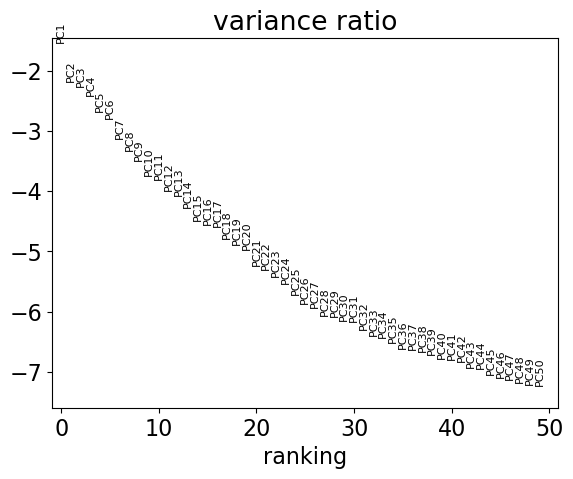

In [252]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

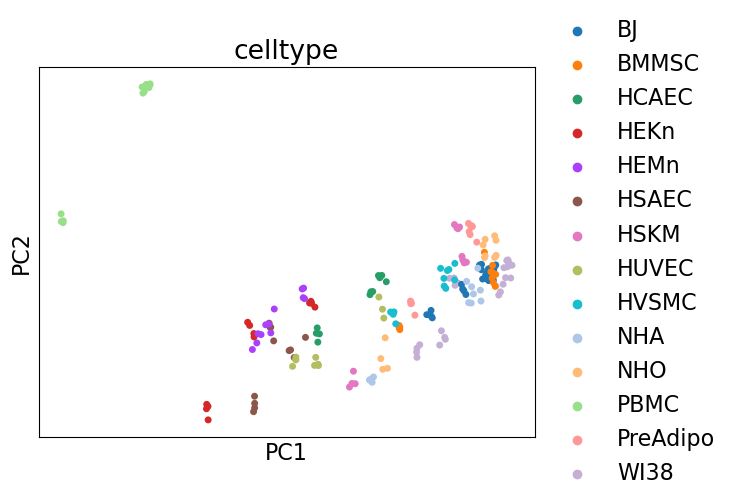

In [253]:
sc.pl.pca(adata, color=["celltype"],  size = 100)

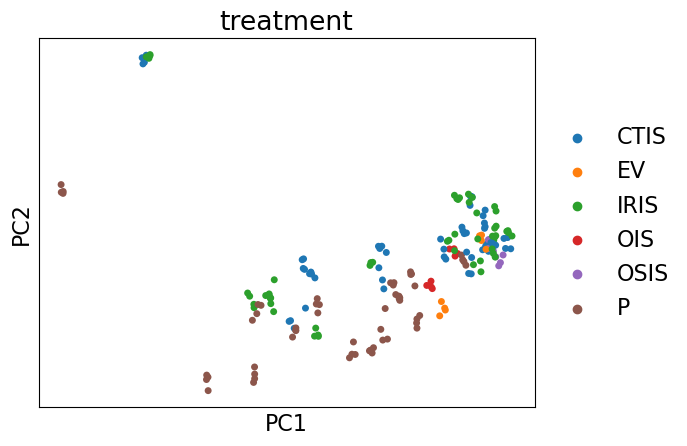

In [254]:
sc.pl.pca(adata, color=["treatment"],  size = 100)

/tmp/ipykernel_28348/1730601515.py:23: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


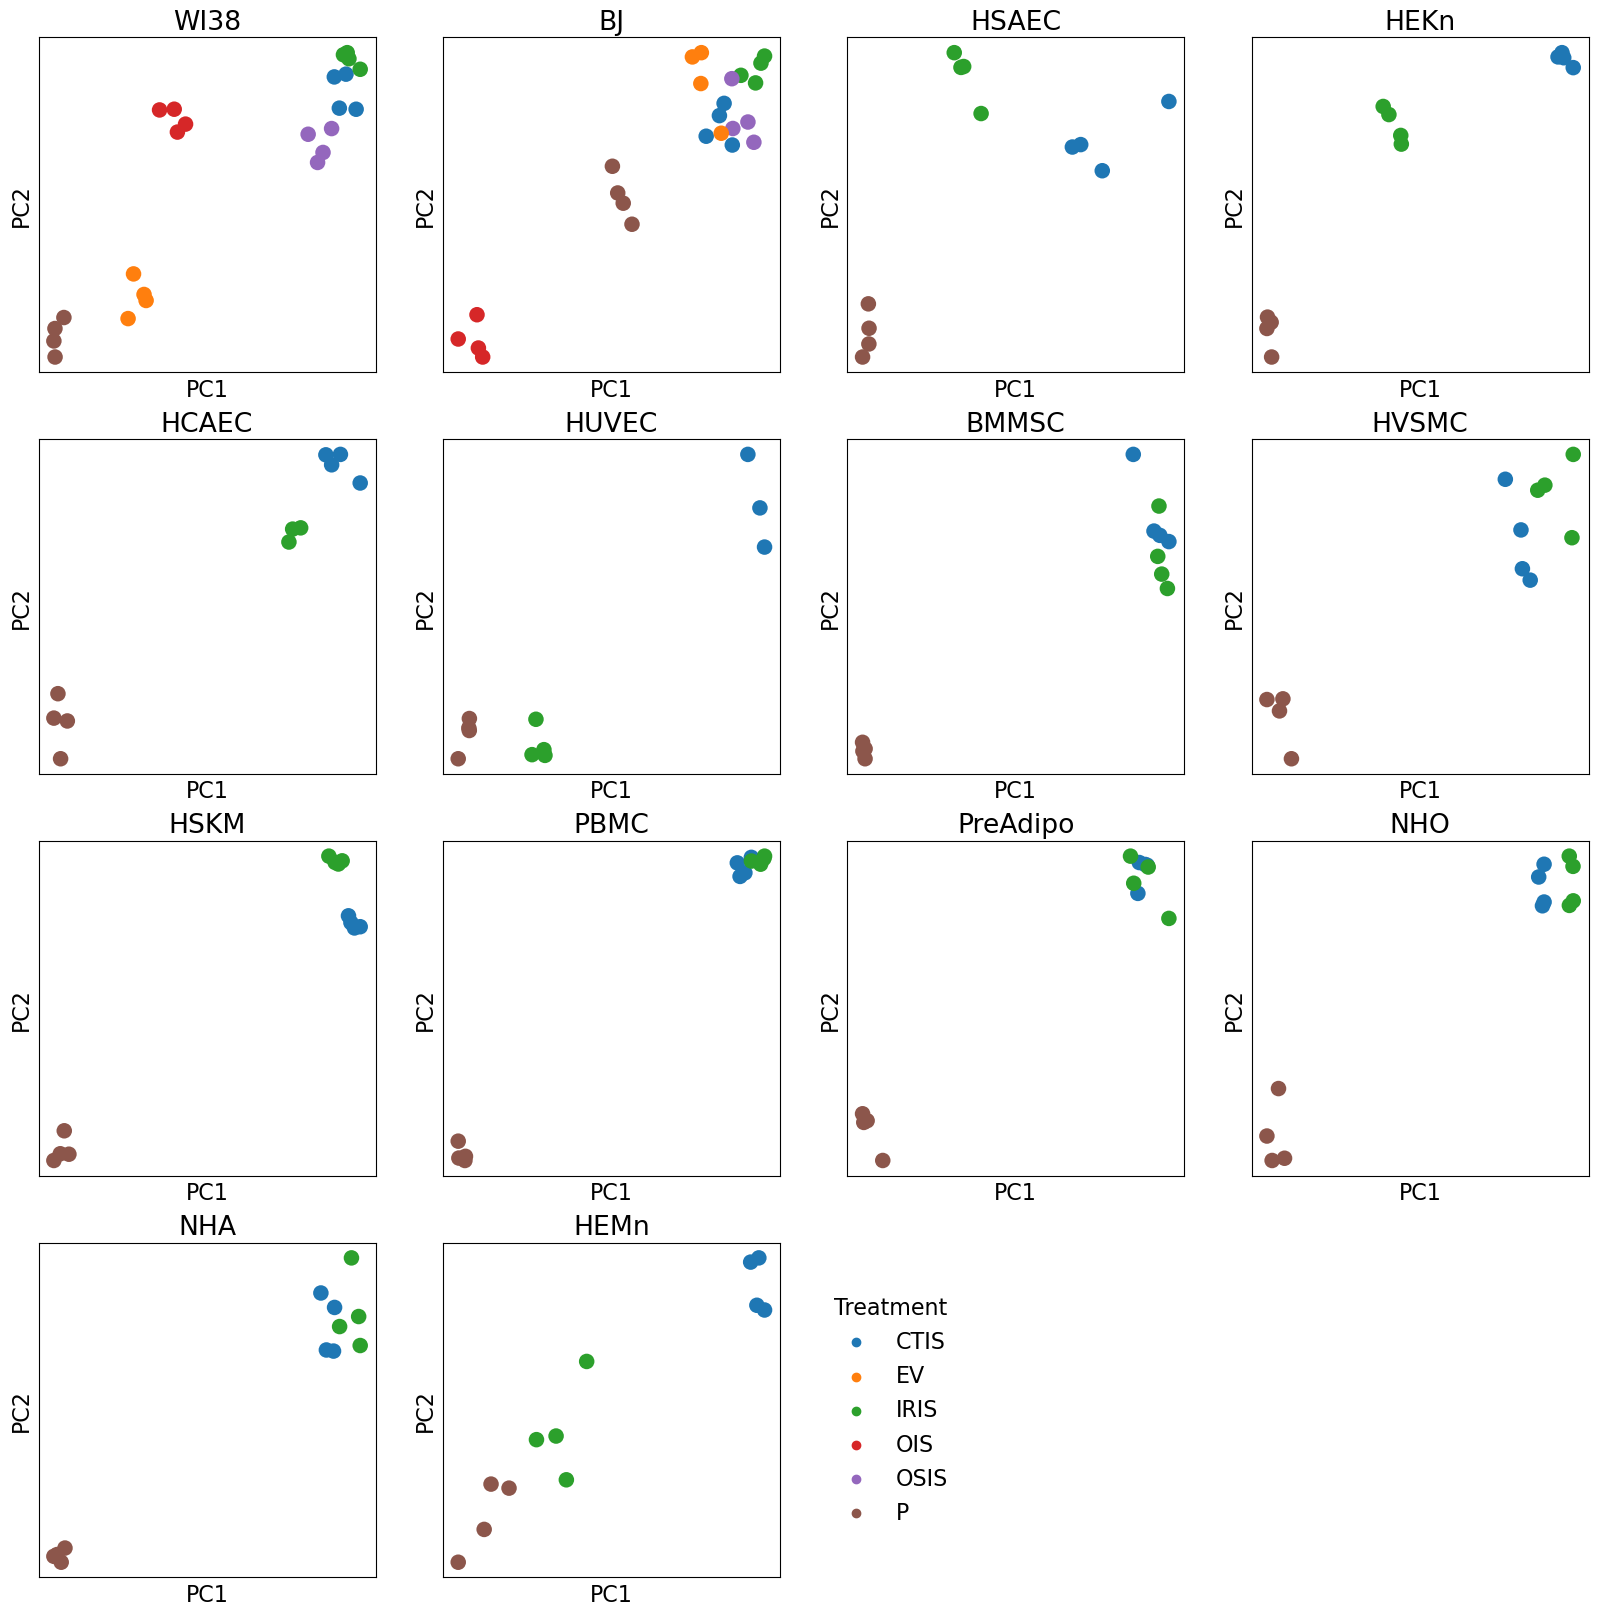

In [255]:
# prepare figure for holding plots for each celltype
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

# show legend only for the last plot
for i, celltype in enumerate(adata.obs['celltype'].unique()):
    ax = axs[i // 4, i % 4]
    sc.pl.pca(adata[adata.obs['celltype'] == celltype], color=['treatment'],  size=500, title=celltype, ax=ax, show=False)

    # hide legend for all but the first plot
    if i > 0:
        ax.get_legend().remove()

# hide empty plots
for i in range(len(adata.obs['celltype'].unique()), 16):
    axs[i // 4, i % 4].axis('off')

# move legend to the bottom right
axs[0, 0].get_legend().set_bbox_to_anchor((2.3, -3.1))

# add legend title
axs[0, 0].get_legend().set_title('Treatment')

plt.tight_layout()
plt.show()

# Classification model

## Add label

In [256]:
non_sen_tratments = ['P', 'EV']

adata.obs['label'] = adata.obs.apply(lambda x: 0 if x['treatment'] in non_sen_tratments else 1, axis=1)
adata.obs

,celltype,treatment,replicate,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,label
obs,,,,,,,,,,,,,,,,
WI38_P_1,WI38,P,1,24076,1.367721e+08,21.554234,27.554661,34.980852,47.617102,2.601749e+06,1.902251,7.163201e+06,5.237326,2.522434e+06,1.844260,0
WI38_P_2,WI38,P,2,25399,1.376799e+08,23.797772,29.552846,36.840060,49.151091,5.445006e+05,0.395483,8.308731e+06,6.034816,5.060257e+05,0.367538,0
WI38_P_3,WI38,P,3,26194,1.401739e+08,24.499691,30.367983,37.707935,49.923827,5.306628e+05,0.378575,8.662190e+06,6.179601,5.112613e+05,0.364733,0
WI38_P_4,WI38,P,4,24820,1.393727e+08,23.070835,28.926199,36.350286,48.794191,5.326578e+05,0.382182,7.833891e+06,5.620823,4.577802e+05,0.328458,0
WI38_CTIS_1,WI38,CTIS,1,28290,1.387274e+08,19.364326,24.971314,32.482062,45.977848,1.500535e+06,1.081643,5.863676e+06,4.226763,1.157875e+06,0.834641,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HEMn_CTIS_4,HEMn,CTIS,4,21914,1.330462e+08,28.390389,33.715357,40.405317,51.221333,1.461346e+06,1.098375,6.923571e+06,5.203885,1.255865e+06,0.943931,1
HEMn_IRIS_1,HEMn,IRIS,1,20129,1.280194e+08,25.906245,31.150416,37.819139,49.307238,1.200979e+06,0.938122,7.040145e+06,5.499279,1.013387e+06,0.791588,1
HEMn_IRIS_2,HEMn,IRIS,2,23897,1.201753e+08,21.164842,26.044765,32.336480,43.929632,1.581037e+06,1.315609,5.207348e+06,4.333127,7.285212e+05,0.606215,1


## Univariate feature selection

In [257]:
def get_features(adata, n_features=500):
    selector = SelectKBest(f_classif, k=n_features)
    selector.fit(adata.X, adata.obs['label'])
    features = selector.get_support(indices=True)
    return features

features = get_features(adata, n_features=500)
features

array([    3,    97,    99,   114,   130,   150,   342,   408,   420,
         527,   598,   672,   680,   685,   690,   725,   726,   764,
         765,   768,   770,   776,   778,   779,   808,   810,   812,
         871,   882,   893,   948,   952,   955,   998,  1011,  1012,
        1027,  1067,  1068,  1070,  1109,  1142,  1166,  1172,  1304,
        1307,  1336,  1343,  1353,  1369,  1386,  1387,  1389,  1396,
        1461,  1463,  1464,  1481,  1483,  1484,  1486,  1487,  1489,
        1490,  1491,  1499,  1527,  1534,  1536,  1542,  1561,  1562,
        1563,  1564,  1565,  1566,  1568,  1569,  1570,  1572,  1575,
        1577,  1583,  1594,  1603,  1611,  1636,  1648,  1649,  1672,
        1710,  1729,  1736,  1739,  1740,  1746,  1747,  1748,  1749,
        1757,  1779,  1781,  1791,  1837,  1949,  1966,  2122,  2168,
        2170,  2172,  2173,  2227,  2238,  2239,  2276,  2296,  2329,
        2331,  2341,  2360,  2379,  2385,  2393,  2406,  2450,  2454,
        2486,  2529,

## Train/test split

In [258]:
def train_test_split(adata, celltype, features):

    train = adata[adata.obs['celltype'] != celltype, features]
    test = adata[adata.obs['celltype'] == celltype, features]
    
    return train.X, train.obs['label'], test.X, test.obs['label']

## Train model for each train/test split

In [259]:
def train_models_for_celltypes(adata, features):
    models = {}
    for celltype in adata.obs['celltype'].unique():
        X_train, y_train, _, _ = train_test_split(adata, celltype, features)
        
        model = LogisticRegression(penalty='l1', solver='liblinear')
        model.fit(X_train, y_train)
        
        models[celltype] = model

    return models

models = train_models_for_celltypes(adata, features)
models

{'WI38': LogisticRegression(penalty='l1', solver='liblinear'),
 'BJ': LogisticRegression(penalty='l1', solver='liblinear'),
 'HSAEC': LogisticRegression(penalty='l1', solver='liblinear'),
 'HEKn': LogisticRegression(penalty='l1', solver='liblinear'),
 'HCAEC': LogisticRegression(penalty='l1', solver='liblinear'),
 'HUVEC': LogisticRegression(penalty='l1', solver='liblinear'),
 'BMMSC': LogisticRegression(penalty='l1', solver='liblinear'),
 'HVSMC': LogisticRegression(penalty='l1', solver='liblinear'),
 'HSKM': LogisticRegression(penalty='l1', solver='liblinear'),
 'PBMC': LogisticRegression(penalty='l1', solver='liblinear'),
 'PreAdipo': LogisticRegression(penalty='l1', solver='liblinear'),
 'NHO': LogisticRegression(penalty='l1', solver='liblinear'),
 'NHA': LogisticRegression(penalty='l1', solver='liblinear'),
 'HEMn': LogisticRegression(penalty='l1', solver='liblinear')}

## Evaluate models

In [260]:
def evaluate_models_for_celltypes(adata, models, features):
    result_test = []
    result_score = []
    for celltype in adata.obs['celltype'].unique():

        _, _, X_test, y_test = train_test_split(adata, celltype, features)
        result_test.extend(y_test)
        model = models[celltype]
        
        y_score = model.predict_proba(X_test)[:, 1]
        result_score.extend(y_score)
    
    return pd.DataFrame({'label': result_test, 'score': result_score, 'celltype': adata.obs['celltype']})

results = evaluate_models_for_celltypes(adata, models, features)
results

,label,score,celltype
obs,,,
WI38_P_1,0,0.003720,WI38
WI38_P_2,0,0.006102,WI38
WI38_P_3,0,0.004363,WI38
WI38_P_4,0,0.005502,WI38
WI38_CTIS_1,1,0.999794,WI38
...,...,...,...
HEMn_CTIS_4,1,0.999824,HEMn
HEMn_IRIS_1,1,0.698712,HEMn
HEMn_IRIS_2,1,0.491344,HEMn


## Plot results

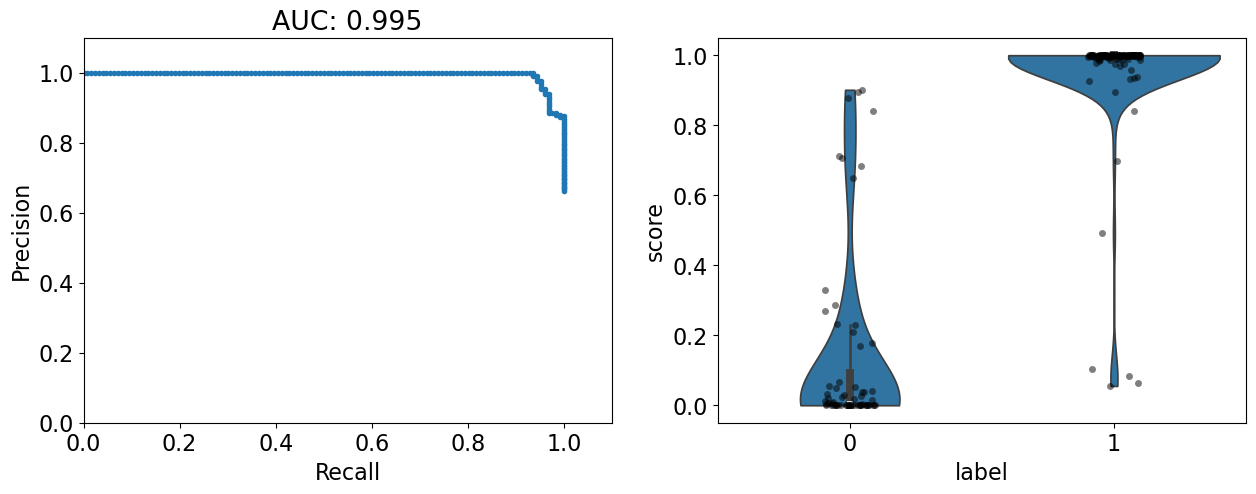

In [261]:

def plot_results(results):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    precision, recall, _ = precision_recall_curve(results['label'], results['score'])
    axs[0].plot(recall, precision, marker='.')
    axs[0].set_xlabel('Recall')
    axs[0].set_ylabel('Precision')
    axs[0].set_title(f"AUC: {round(auc(recall, precision), 3)}")

    axs[0].set_xlim([0.0, 1.1])
    axs[0].set_ylim([0.0, 1.1])

    sns.violinplot(x='label', y='score', data=results, cut=0, ax=axs[1])
    sns.stripplot(x='label', y='score', data=results, jitter=True, color='black', alpha=0.5, ax=axs[1])

    return fig

fig = plot_results(results)
plt.show()

## Select binary threshold

In [262]:
def select_threshold(results):
    precision, recall, thresholds = precision_recall_curve(results['label'], results['score'])
    f1 = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[np.argmax(f1)]
    return best_threshold

threshold = select_threshold(results)
threshold

np.float64(0.8961187839862353)

In [263]:
results['prediction'] = results['score'].apply(lambda x: 1 if x > threshold else 0)
results

,label,score,celltype,prediction
obs,,,,
WI38_P_1,0,0.003720,WI38,0
WI38_P_2,0,0.006102,WI38,0
WI38_P_3,0,0.004363,WI38,0
WI38_P_4,0,0.005502,WI38,0
WI38_CTIS_1,1,0.999794,WI38,1
...,...,...,...,...
HEMn_CTIS_4,1,0.999824,HEMn,1
HEMn_IRIS_1,1,0.698712,HEMn,0
HEMn_IRIS_2,1,0.491344,HEMn,0


## Get misclassified samples

In [264]:
def get_misclassified_samples(results, threshold=0.5):
    misclassified = {}
    for celltype in results['celltype'].unique():
        celltype_results = results[results['celltype'] == celltype]
        misclassified[celltype] = celltype_results[celltype_results['label'] != (celltype_results['score'] > threshold)].index.values.tolist()
    return misclassified

misclassified = get_misclassified_samples(results, threshold)
misclassified

{'WI38': [],
 'BJ': ['BJ_EV_4', 'BJ_OIS_3'],
 'HSAEC': [],
 'HEKn': [],
 'HCAEC': [],
 'HUVEC': ['HUVEC_IRIS_1', 'HUVEC_IRIS_2', 'HUVEC_IRIS_3', 'HUVEC_IRIS_4'],
 'BMMSC': [],
 'HVSMC': [],
 'HSKM': [],
 'PBMC': [],
 'PreAdipo': [],
 'NHO': [],
 'NHA': [],
 'HEMn': ['HEMn_IRIS_1', 'HEMn_IRIS_2', 'HEMn_IRIS_3']}

## Pick the best number of features to select

  0%|          | 0/24 [00:00<?, ?it/s]

/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
  4%|▍         | 1/24 [00:00<00:09,  2.48it/s]/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/jovyan/my-conda-envs/data_process/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the num

Text(0, 0.5, 'AUC-PR')

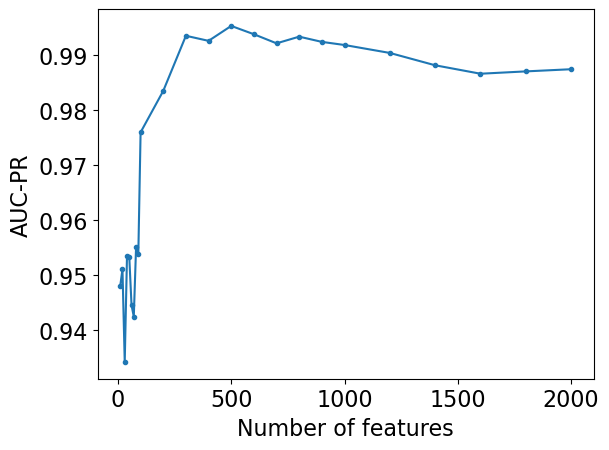

In [265]:
feat_to_auc = []

for n_features in tqdm.tqdm([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000]):
    features = SelectKBest(f_classif, k=n_features).fit(adata.X, adata.obs['label']).get_support(indices=True)
    models = train_models_for_celltypes(adata, features)
    results = evaluate_models_for_celltypes(adata, models, features)
    precision, recall, _ = precision_recall_curve(results['label'], results['score'])
    auc_score = auc(recall, precision)
    threshold = select_threshold(results)
    feat_to_auc.append((n_features, auc_score, threshold))

df = pd.DataFrame(feat_to_auc, columns=['n_features', 'auc', 'threshold'])
plt.plot(df['n_features'], df['auc'], marker='.')
plt.xlabel('Number of features')
plt.ylabel('AUC-PR')

In [266]:
# get the best number of features
best_num_features = df[df['auc'] == df['auc'].max()]['n_features'].values[0]
best_num_features

np.int64(500)

## Train models again with optimal number of features

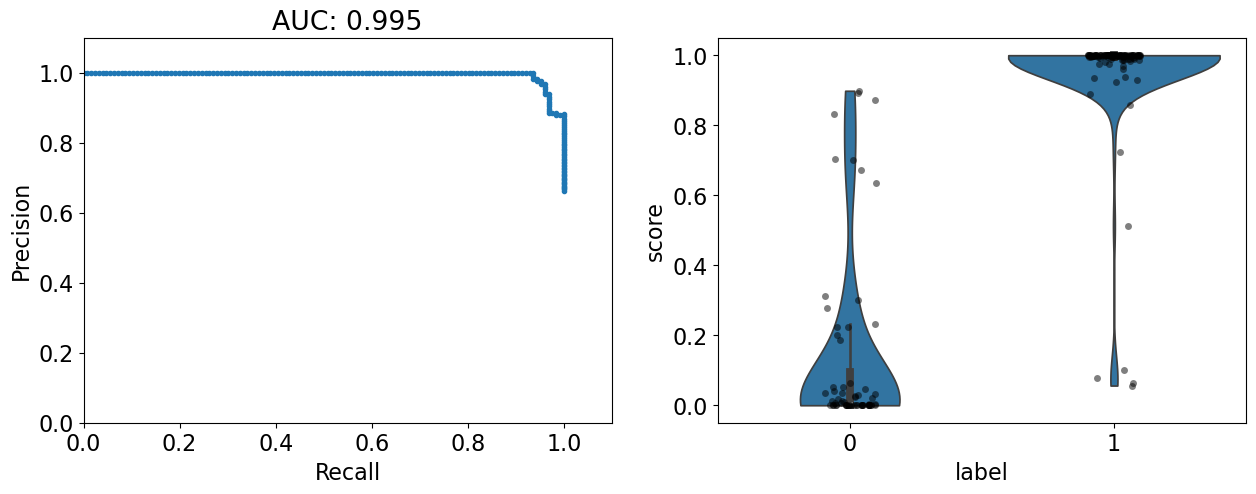

{'WI38': [],
 'BJ': ['BJ_OIS_1', 'BJ_OIS_3'],
 'HSAEC': [],
 'HEKn': [],
 'HCAEC': [],
 'HUVEC': ['HUVEC_IRIS_1', 'HUVEC_IRIS_2', 'HUVEC_IRIS_3', 'HUVEC_IRIS_4'],
 'BMMSC': [],
 'HVSMC': [],
 'HSKM': [],
 'PBMC': [],
 'PreAdipo': [],
 'NHO': [],
 'NHA': [],
 'HEMn': ['HEMn_IRIS_1', 'HEMn_IRIS_2', 'HEMn_IRIS_3']}

In [267]:
features = get_features(adata, n_features=best_num_features)
models = train_models_for_celltypes(adata, features)
results = evaluate_models_for_celltypes(adata, models, features)
threshold = select_threshold(results)
misclassified = get_misclassified_samples(results, threshold)
fig = plot_results(results)
plt.show()
misclassified

## Get features with importance above threshold

In [268]:
def get_top_features_for_celltype(models, threshold):
    top_features = {}
    for celltype, model in models.items():
        coef = model.coef_[0]
        top_features[celltype] = [features[np.abs(coef) > threshold], coef[np.abs(coef) > threshold]]
    
    return top_features

top_features = get_top_features_for_celltype(models, 0.02)
top_features

{'WI38': [array([  672,   690,  1343,  1534,  1562,  1636,  3514,  3886,  3905,
          4404,  5100,  5246,  7149, 10216, 10495, 11861]),
  array([-0.38065386,  1.86536887, -0.57069918, -0.66493136, -0.0203718 ,
          0.19170683,  0.91188217, -0.03139869, -0.35565553, -1.24404077,
          0.31165944,  0.11791786, -0.24219764, -0.02358639, -0.03064285,
          0.11938276])],
 'BJ': [array([  690,  1343,  1561,  1562,  1636,  3514,  3883,  3886,  4404,
          4607,  5100,  5246,  7149,  9587, 10184, 10495, 12019]),
  array([ 0.89010762, -0.32810416, -0.606006  , -0.17794231,  0.40688701,
          0.61341096, -0.14425282, -0.14012239, -0.76398272, -0.25822568,
          0.68408678,  0.23502472, -0.40665806, -0.19746954,  0.05343231,
         -0.16044333,  0.33195879])],
 'HSAEC': [array([  672,   690,  1343,  1534,  1561,  1562,  1636,  3514,  3905,
          4404,  5100,  5246,  7149, 10693]),
  array([-0.27949434,  1.84549625, -0.35783831, -1.01923418, -0.24331981,
       

## Get overlaping features 

In [269]:
def get_overlap(top_genes):
    gene_counts = Counter()
    for genes in top_genes.values():
        gene_counts.update(genes[0])

    common_genes = [gene for gene, count in gene_counts.items() if count == 14]
    return np.array(common_genes)

common_features = get_overlap(top_features)
common_features

array([ 690, 3514, 4404, 7149])

In [270]:
feature_names = adata.var_names[common_features]
feature_names

Index(['ENSG00000162772', 'ENSG00000130513', 'ENSG00000183856',
       'ENSG00000129195'],
      dtype='object', name='converted_alias')

## Get importance of common features

In [271]:
def get_feature_importance(top_features, common_features):
    feature_importance = {}
    for celltype, genes in top_features.items():
        feature_importance[celltype] = genes[1][np.isin(genes[0], common_features)]
    
    return feature_importance

feature_importance = get_feature_importance(top_features, common_features)
feature_importance

{'WI38': array([ 1.86536887,  0.91188217, -1.24404077, -0.24219764]),
 'BJ': array([ 0.89010762,  0.61341096, -0.76398272, -0.40665806]),
 'HSAEC': array([ 1.84549625,  0.83269977, -0.81401996, -0.24769073]),
 'HEKn': array([ 1.81618119,  0.96763389, -1.16434502, -0.24561699]),
 'HCAEC': array([ 1.73229375,  1.04085388, -1.19060195, -0.27534955]),
 'HUVEC': array([ 1.70718773,  0.73909778, -0.06612388, -0.04170215]),
 'BMMSC': array([ 1.81354027,  0.96334474, -1.10781361, -0.27581609]),
 'HVSMC': array([ 1.79253828,  0.86069736, -1.07341452, -0.22488445]),
 'HSKM': array([ 1.80063616,  0.95373977, -1.07443614, -0.27609876]),
 'PBMC': array([ 1.71066326,  1.01998626, -1.08979097, -0.1149325 ]),
 'PreAdipo': array([ 1.87931336,  0.92034921, -1.13118507, -0.24473851]),
 'NHO': array([ 1.82786699,  0.95825972, -1.09138947, -0.21782188]),
 'NHA': array([ 1.89286221,  0.83728639, -1.10369334, -0.17785554]),
 'HEMn': array([ 1.81085991,  1.22163956, -1.33693316, -0.17060072])}

## Get mean coeficient

In [272]:
coefs = np.array(list(feature_importance.values())).mean(axis=0)
coefs

array([ 1.7417797 ,  0.91720582, -1.01798361, -0.22585454])

## Classify samples using common features and their coeficients

In [273]:
def classify_samples(adata, features, coefs):
    X = adata[:, features].X
    y = adata.obs['label']
    preds = X @ coefs
    return pd.DataFrame({'label': y, 'score': preds, 'celltype': adata.obs['celltype']})

scores = classify_samples(adata, common_features, coefs)
scores

,label,score,celltype
obs,,,
WI38_P_1,0,8.303991,WI38
WI38_P_2,0,8.816506,WI38
WI38_P_3,0,8.802997,WI38
WI38_P_4,0,8.721087,WI38
WI38_CTIS_1,1,15.231890,WI38
...,...,...,...
HEMn_CTIS_4,1,18.576537,HEMn
HEMn_IRIS_1,1,13.312060,HEMn
HEMn_IRIS_2,1,12.926727,HEMn


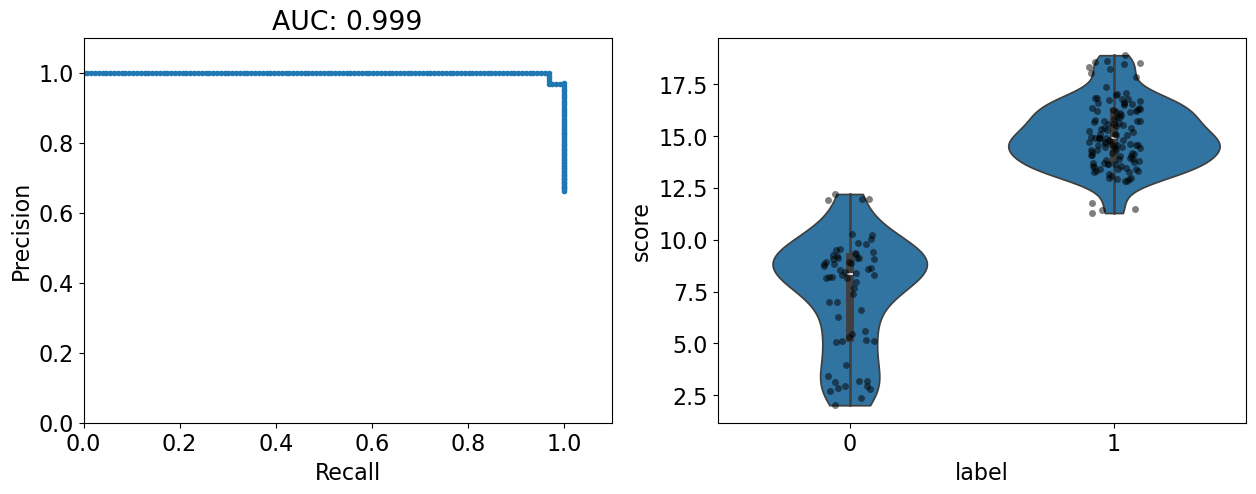

In [274]:
fig = plot_results(scores)
plt.show()

In [275]:
threshold = select_threshold(scores)
print(f"Threshold: {threshold}")
misclassified = get_misclassified_samples(scores, threshold)
misclassified

Threshold: 11.28561026448222


{'WI38': [],
 'BJ': ['BJ_IRIS_3'],
 'HSAEC': [],
 'HEKn': [],
 'HCAEC': [],
 'HUVEC': [],
 'BMMSC': [],
 'HVSMC': [],
 'HSKM': [],
 'PBMC': [],
 'PreAdipo': [],
 'NHO': [],
 'NHA': [],
 'HEMn': ['HEMn_P_1', 'HEMn_P_2', 'HEMn_P_3', 'HEMn_P_4']}

# Test on independent data

In [276]:
def load_counts_with_metadata(counts_path, metadata_path):
    counts = pd.read_csv(counts_path, sep = '\t', index_col=0).T
    adata = sc.AnnData(counts)

    adata.obs['sample'] = adata.obs_names 
    adata.var_names_make_unique()

    metadata = pd.read_excel(metadata_path)
    # add metadata to observations
    adata.obs = adata.obs.reset_index().merge(metadata, how="left").set_index('index')
    adata.obs['label'] = adata.obs.apply(lambda x: 1 if str(x['condition']).startswith('sen') else 0, axis=1)

    return adata

In [277]:
COUTNS_PATH = "/home/jovyan/wf-SenCID/data/23_all_sample_gene_counts.txt"
METADATA_PATH = "/home/jovyan/wf-SenCID/data/23_coldata.xlsx"


ext_adata = load_counts_with_metadata(
    COUTNS_PATH,
    METADATA_PATH
)
ext_adata.obs

,sample,condition,seqtype,label
index,,,,
Cyc1_RNA_S7_R1_001,Cyc1_RNA_S7_R1_001,cycling,RNA,0
Cyc2_RNA_S8_R1_001,Cyc2_RNA_S8_R1_001,cycling,RNA,0
E1_RNA_S10_R1_001,E1_RNA_S10_R1_001,sen-etop,RNA,1
E2_RNA_S11_R1_001,E2_RNA_S11_R1_001,sen-etop,RNA,1
E3_RNA_S12_R1_001,E3_RNA_S12_R1_001,sen-etop,RNA,1
IR1_RNA_S1_R1_001,IR1_RNA_S1_R1_001,sen-ir,RNA,1
IR2_RNA_S2_R1_001,IR2_RNA_S2_R1_001,sen-ir,RNA,1
IR3_RNA_S3_R1_001,IR3_RNA_S3_R1_001,sen-ir,RNA,1
Q1_RNA_S4_R1_001,Q1_RNA_S4_R1_001,quiescent,RNA,0


In [287]:
def classify_samples(adata, features, coefs):
    X = adata[:, features].X
    y = adata.obs['label']
    preds = X @ coefs
    return pd.DataFrame({'label': y, 'score': preds})

scores = classify_samples(ext_adata[ext_adata.obs['seqtype'] != 'Ribo'], feature_names, coefs)
scores

,label,score
index,,
Cyc1_RNA_S7_R1_001,0,-707.079001
Cyc2_RNA_S8_R1_001,0,-676.875110
E1_RNA_S10_R1_001,1,5431.252444
E2_RNA_S11_R1_001,1,6636.235407
E3_RNA_S12_R1_001,1,7400.650663
IR1_RNA_S1_R1_001,1,2165.900931
IR2_RNA_S2_R1_001,1,2523.455628
IR3_RNA_S3_R1_001,1,2057.132070
Q1_RNA_S4_R1_001,0,1057.495778


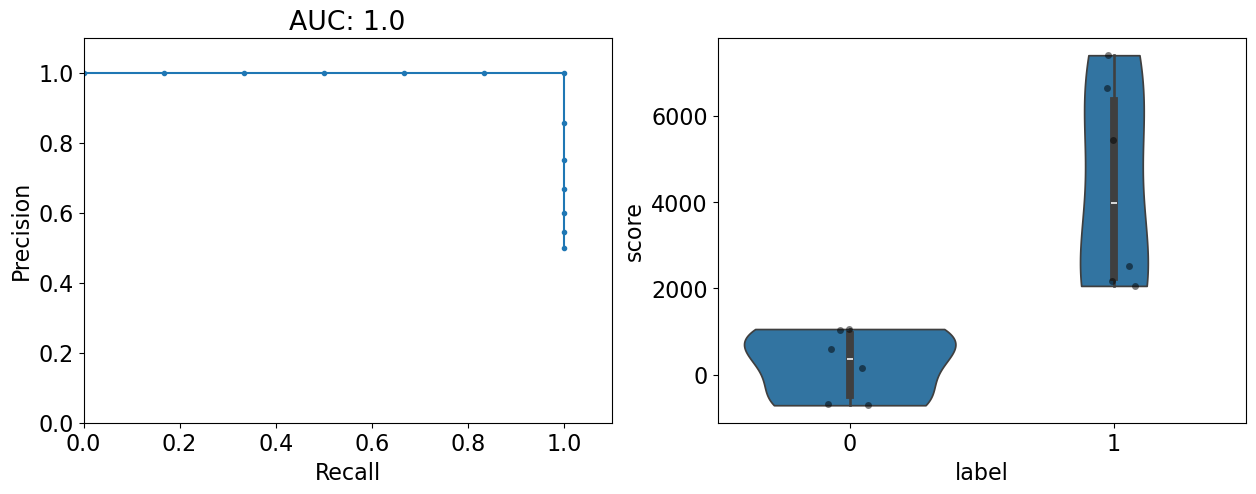

In [288]:
fig = plot_results(scores)
plt.show()